In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
warnings.filterwarnings('ignore')

from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import LabelEncoder
import shap

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11
})
sns.set_palette('husl')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print('✅ Imports complete')

✅ Imports complete


In [ ]:

orders           = pd.read_csv('/content/final_orders.csv', parse_dates=['created_at'])
order_items      = pd.read_csv('/content/final_order_items.csv')
products         = pd.read_csv('/content/final_products.csv')
users            = pd.read_csv('/content/final_users.csv')
inventory        = pd.read_csv('/content/final_inventory.csv')
payments         = pd.read_csv('/content/final_payments.csv')
competitor_prices = pd.read_csv('/content/real_competitor_prices.csv')
discounts        = pd.read_csv('/content/real_discounts.csv')
product_demand   = pd.read_csv('/content/real_product_demand.csv')

print('Dataset shapes:')
for name, df_tmp in [('orders', orders), ('order_items', order_items),
                     ('products', products), ('users', users),
                     ('inventory', inventory), ('payments', payments),
                     ('competitor_prices', competitor_prices),
                     ('discounts', discounts), ('product_demand', product_demand)]:
    print(f'  {name:<20} {df_tmp.shape}')

Dataset shapes:
  orders               (5000, 7)
  order_items          (9954, 5)
  products             (20, 2)
  users                (800, 1)
  inventory            (20, 3)
  payments             (5000, 3)
  competitor_prices    (5000, 5)
  discounts            (5000, 6)
  product_demand       (5000, 6)


In [ ]:
print("\n📌 COLUMN NAMES IN EACH TABLE:\n")

tables = {
    "orders": orders,
    "order_items": order_items,
    "products": products,
    "users": users,
    "inventory": inventory,
    "payments": payments,
    "competitor_prices": competitor_prices,
    "discounts": discounts,
    "product_demand": product_demand
}

for name, df in tables.items():
    print(f"\n{name.upper()} COLUMNS:")
    print(df.columns.tolist())


📌 COLUMN NAMES IN EACH TABLE:


ORDERS COLUMNS:
['order_id', 'user_id', 'created_at', 'total_amount', 'tax_amount', 'discount_amount', 'order_status']

ORDER_ITEMS COLUMNS:
['order_item_id', 'order_id', 'product_id', 'quantity', 'unit_price']

PRODUCTS COLUMNS:
['product_id', 'price']

USERS COLUMNS:
['user_id']

INVENTORY COLUMNS:
['inventory_id', 'product_id', 'cost_price']

PAYMENTS COLUMNS:
['payment_id', 'order_id', 'payment_status']

COMPETITOR_PRICES COLUMNS:
['competitor_price_id', 'product_id', 'competitor_name', 'competitor_price', 'date']

DISCOUNTS COLUMNS:
['discount_id', 'product_id', 'discount_percent', 'start_date', 'end_date', 'campaign_name']

PRODUCT_DEMAND COLUMNS:
['demand_id', 'product_id', 'date', 'quantity_sold', 'price_at_that_time', 'demand_level']


In [ ]:
# ── Integrity Checks ─────────────────────────────────────────────
print('=== DATA INTEGRITY CHECKS ===')

# 1. Null checks
for name, df in [
    ('orders', orders),
    ('order_items', order_items),
    ('products', products),
    ('inventory', inventory)
]:
    nulls = df.isnull().sum().sum()
    print(f'  [{"PASS" if nulls == 0 else "FAIL"}] {name}: {nulls} nulls')


# 2. FK integrity: order_items → orders
orphan_items = (~order_items['order_id'].isin(orders['order_id'])).sum()
print(f'  [{"PASS" if orphan_items == 0 else "FAIL"}] order_items → orders FK: {orphan_items} orphans')


# 3. FK integrity: order_items → products
orphan_products = (~order_items['product_id'].isin(products['product_id'])).sum()
print(f'  [{"PASS" if orphan_products == 0 else "FAIL"}] order_items → products FK: {orphan_products} orphans')


# 4. COST < SELLING PRICE constraint
price_check = (
    order_items[['product_id','unit_price']]
    .merge(inventory[['product_id','cost_price']], on='product_id', how='left')
)

violations = (price_check['cost_price'] >= price_check['unit_price']).sum()

print(f'  [{"PASS" if violations == 0 else "FAIL"}] cost < selling price: {violations} violations')


print('\n✅ Integrity checks completed')

=== DATA INTEGRITY CHECKS ===
  [PASS] orders: 0 nulls
  [PASS] order_items: 0 nulls
  [PASS] products: 0 nulls
  [PASS] inventory: 0 nulls
  [PASS] order_items → orders FK: 0 orphans
  [PASS] order_items → products FK: 0 orphans
  [PASS] cost < selling price: 0 violations

✅ Integrity checks completed


DATA MERGING AND BASE TABLE

In [ ]:
# ── RELATIONAL FEATURE TABLE BUILD ───────────────────────────────

df = (
    order_items.rename(columns={
        'quantity': 'oi_quantity',
        'unit_price': 'oi_unit_price'
    })

    # ORDER LEVEL (Demand Timing)
    .merge(
        orders[['order_id', 'created_at']]
        .rename(columns={'created_at': 'ord_date'}),
        on='order_id'
    )

    # PRODUCT LEVEL (Catalog Price)
    .merge(
        products.rename(columns={'price': 'prod_list_price'}),
        on='product_id'
    )

    # SUPPLY LEVEL (Cost Constraint)
    .merge(
        inventory[['product_id', 'cost_price']]
        .rename(columns={'cost_price': 'inv_cost'}),
        on='product_id',
        how='left'
    )
)

In [ ]:
df = df.sort_values(['product_id', 'ord_date']).reset_index(drop=True)

In [ ]:
df['profit'] = (df['oi_unit_price'] - df['inv_cost']) * df['oi_quantity']

In [ ]:
df['month'] = df['ord_date'].dt.month
df['day_of_week'] = df['ord_date'].dt.dayofweek

In [ ]:
print(f'Base table shape: {df.shape}')
df.head()

Base table shape: (9954, 11)


,order_item_id,order_id,product_id,oi_quantity,oi_unit_price,ord_date,prod_list_price,inv_cost,profit,month,day_of_week
0,6289755,6868012,1020496,6,11784,2023-01-01,11784,8055.022353,22373.865879,1,6
1,9331011,9707015,1020496,5,11784,2023-01-01,11784,8055.022353,18644.888233,1,6
2,2647555,6246418,1020496,5,11784,2023-01-01,11784,8055.022353,18644.888233,1,6
3,3632405,4423951,1020496,6,11784,2023-01-02,11784,8055.022353,22373.865879,1,0
4,2921009,457451,1020496,6,11784,2023-01-04,11784,8055.022353,22373.865879,1,2


In [ ]:
# latest_comp = (
#     competitor_prices
#     .sort_values('date')
#     .groupby('product_id')
#     .tail(1)
#     .rename(columns={'competitor_price':'comp_price'})
# )

# df = df.merge(
#     latest_comp[['product_id','comp_price']],
#     on='product_id',
#     how='left'
# )

# ✅ CELL 10 — Time-aligned competitor price merge (no leakage)
competitor_prices['date'] = pd.to_datetime(competitor_prices['date'])
df['ord_date'] = pd.to_datetime(df['ord_date'])

comp_sorted = competitor_prices.sort_values('date')

df = pd.merge_asof(
    df.sort_values('ord_date'),
    comp_sorted[['product_id', 'date', 'competitor_price']].rename(columns={'competitor_price': 'comp_price'}),
    left_on='ord_date',
    right_on='date',
    by='product_id',
    direction='backward'
).drop(columns='date')

df = df.sort_values(['product_id', 'ord_date']).reset_index(drop=True)
print(f"comp_price nulls: {df['comp_price'].isnull().sum()}")

comp_price nulls: 34


In [ ]:
# latest_disc = (
#     discounts
#     .sort_values('end_date')
#     .groupby('product_id')
#     .tail(1)
#     .rename(columns={'discount_percent':'disc_percent'})
# )

# df = df.merge(
#     latest_disc[['product_id','disc_percent']],
#     on='product_id',
#     how='left'
# )

# ✅ CELL 11 — Time-aligned discount merge (no leakage)
# discounts['start_date'] = pd.to_datetime(discounts['start_date'])
# discounts['end_date']   = pd.to_datetime(discounts['end_date'])

# def get_active_discount(order_date, product_id):
#     mask = (
#         (discounts['product_id'] == product_id) &
#         (discounts['start_date'] <= order_date) &
#         (discounts['end_date']   >= order_date)
#     )
#     matched = discounts.loc[mask, 'discount_percent']
#     return matched.iloc[-1] if len(matched) > 0 else 0.0

# df['disc_percent'] = [
#     get_active_discount(row['ord_date'], row['product_id'])
#     for _, row in df.iterrows()
# ]
# print(f"Discount applied rows: {(df['disc_percent'] > 0).sum()}")
# ✅ CELL 11 — Vectorized discount merge (no row-by-row loop)

discounts['start_date'] = pd.to_datetime(discounts['start_date'])
discounts['end_date']   = pd.to_datetime(discounts['end_date'])

# Cross join orders with discounts on product_id, then filter by date range
disc_filtered = (
    df[['order_id', 'product_id', 'ord_date']]
    .merge(
        discounts[['product_id', 'start_date', 'end_date', 'discount_percent']],
        on='product_id',
        how='left'
    )
)

# Keep only rows where order date falls within the discount window
disc_filtered = disc_filtered[
    (disc_filtered['ord_date'] >= disc_filtered['start_date']) &
    (disc_filtered['ord_date'] <= disc_filtered['end_date'])
]

# If multiple discounts match, take the last one (same logic as before)
disc_filtered = (
    disc_filtered
    .sort_values(['order_id', 'product_id', 'end_date'])
    .groupby(['order_id', 'product_id'], as_index=False)
    .last()[['order_id', 'product_id', 'discount_percent']]
)

# Merge back and fill 0 for no active discount
df = df.merge(disc_filtered, on=['order_id', 'product_id'], how='left')
df['disc_percent'] = df['discount_percent'].fillna(0)
df.drop(columns='discount_percent', inplace=True)

print(f"Discount applied rows: {(df['disc_percent'] > 0).sum()}")

Discount applied rows: 9895


In [ ]:
df['disc_percent'] = df['disc_percent'].fillna(0)
df['comp_price']   = df['comp_price'].fillna(df['oi_unit_price'])

In [ ]:
print(df.columns)

Index(['order_item_id', 'order_id', 'product_id', 'oi_quantity',
       'oi_unit_price', 'ord_date', 'prod_list_price', 'inv_cost', 'profit',
       'month', 'day_of_week', 'comp_price', 'disc_percent'],
      dtype='object')


EDA

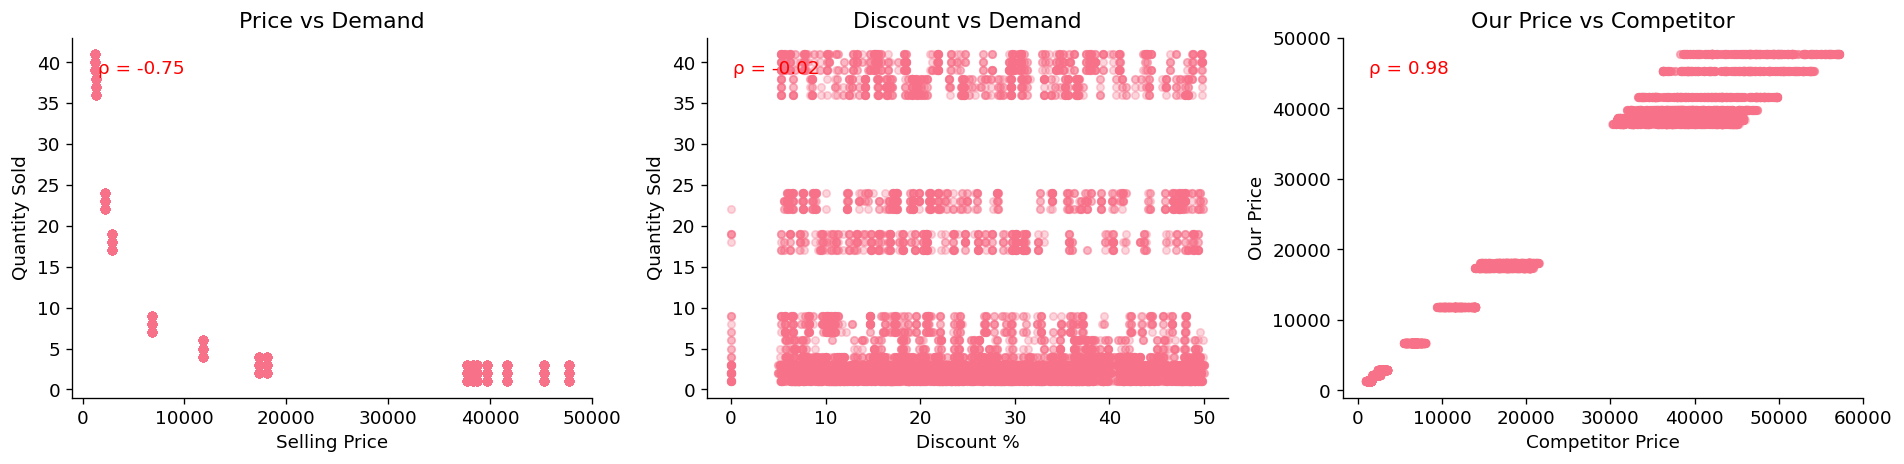

Price-Demand corr: -0.755 | Discount-Demand corr: -0.018


In [ ]:
# ── 4.1 Price vs Demand Scatter ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Price vs Demand
axes[0].scatter(df['oi_unit_price'], df['oi_quantity'], alpha=0.3, s=20)
axes[0].set(xlabel='Selling Price', ylabel='Quantity Sold', title='Price vs Demand')

corr_pq = df['oi_unit_price'].corr(df['oi_quantity'])
axes[0].text(0.05, 0.9, f'ρ = {corr_pq:.2f}', transform=axes[0].transAxes, color='red')


# Discount vs Demand
axes[1].scatter(df['disc_percent'], df['oi_quantity'], alpha=0.3, s=20)
axes[1].set(xlabel='Discount %', ylabel='Quantity Sold', title='Discount vs Demand')

corr_dq = df['disc_percent'].corr(df['oi_quantity'])
axes[1].text(0.05, 0.9, f'ρ = {corr_dq:.2f}', transform=axes[1].transAxes, color='red')


# Competitor Price vs Our Price
axes[2].scatter(df['comp_price'], df['oi_unit_price'], alpha=0.3, s=20)
axes[2].set(xlabel='Competitor Price', ylabel='Our Price', title='Our Price vs Competitor')

corr_cp = df['comp_price'].corr(df['oi_unit_price'])
axes[2].text(0.05, 0.9, f'ρ = {corr_cp:.2f}', transform=axes[2].transAxes, color='red')


plt.tight_layout()
plt.savefig('eda_scatter.png', bbox_inches='tight')
plt.show()

print(f'Price-Demand corr: {corr_pq:.3f} | Discount-Demand corr: {corr_dq:.3f}')

In [ ]:
df['margin'] = (df['oi_unit_price'] - df['inv_cost']) / df['oi_unit_price']

In [ ]:
# df['lag_1_quantity'] = df.groupby('product_id')['oi_quantity'].shift(1)
# df['lag_7_quantity'] = df.groupby('product_id')['oi_quantity'].shift(7)

In [ ]:
# df['rolling_7_quantity'] = (
#     df.groupby('product_id')['oi_quantity']
#       .rolling(7)
#       .mean()
#       .reset_index(0, drop=True)
# )

In [ ]:
# df.fillna(0, inplace=True)
# ✅ CELL 19 — Only fill non-lag columns; lag NaNs are handled later via dropna
fill_cols = ['comp_price', 'disc_percent', 'margin']
df[fill_cols] = df[fill_cols].fillna(0)

# DO NOT fillna lag features here — they will be dropped in daily_clean (Cell 36)
print(f"Nulls remaining: {df.isnull().sum()[df.isnull().sum() > 0]}")

Nulls remaining: Series([], dtype: int64)


In [ ]:
print(df.columns)

Index(['order_item_id', 'order_id', 'product_id', 'oi_quantity',
       'oi_unit_price', 'ord_date', 'prod_list_price', 'inv_cost', 'profit',
       'month', 'day_of_week', 'comp_price', 'disc_percent', 'margin'],
      dtype='object')


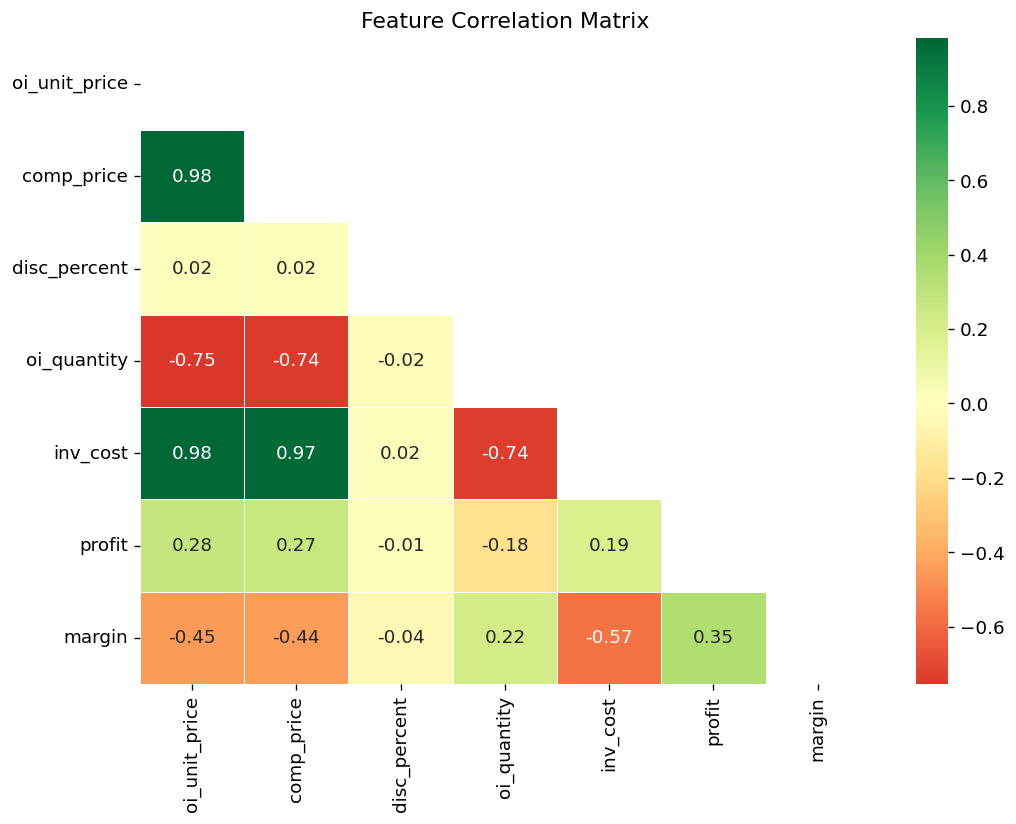

In [ ]:
# ── 4.2 Correlation Heatmap ─────────────────────────────────────

numeric_cols = [
    'oi_unit_price',
    'comp_price',
    'disc_percent',
    'oi_quantity',
    'inv_cost',
    'profit',
    'margin'
]

corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    mask=mask,
    ax=ax,
    linewidths=0.5
)

ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('eda_heatmap.png', bbox_inches='tight')
plt.show()

In [ ]:
df['price_segment'] = pd.qcut(
    df['prod_list_price'],
    q=3,
    labels=['Low Price', 'Medium Price', 'High Price']
)

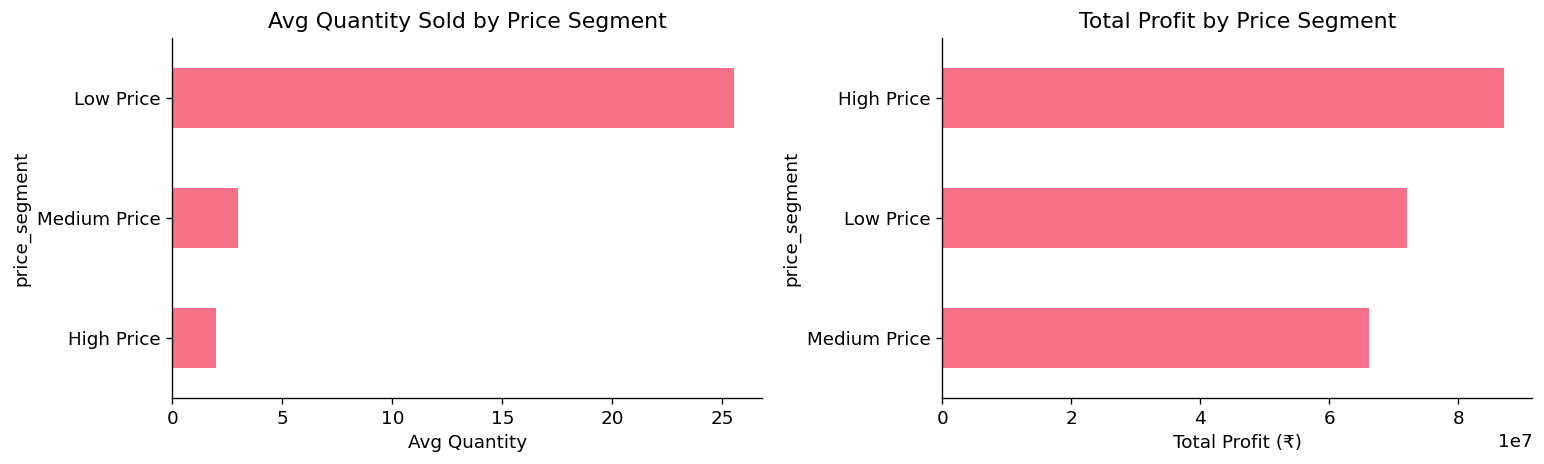

In [ ]:
# ── 4.3 Demand distribution by price segment ─────────────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df.groupby('price_segment')['oi_quantity'].mean().sort_values().plot(
    kind='barh', ax=axes[0])
axes[0].set(title='Avg Quantity Sold by Price Segment', xlabel='Avg Quantity')

df.groupby('price_segment')['profit'].sum().sort_values().plot(
    kind='barh', ax=axes[1])
axes[1].set(title='Total Profit by Price Segment', xlabel='Total Profit (₹)')

plt.tight_layout()
plt.savefig('eda_segment.png', bbox_inches='tight')
plt.show()

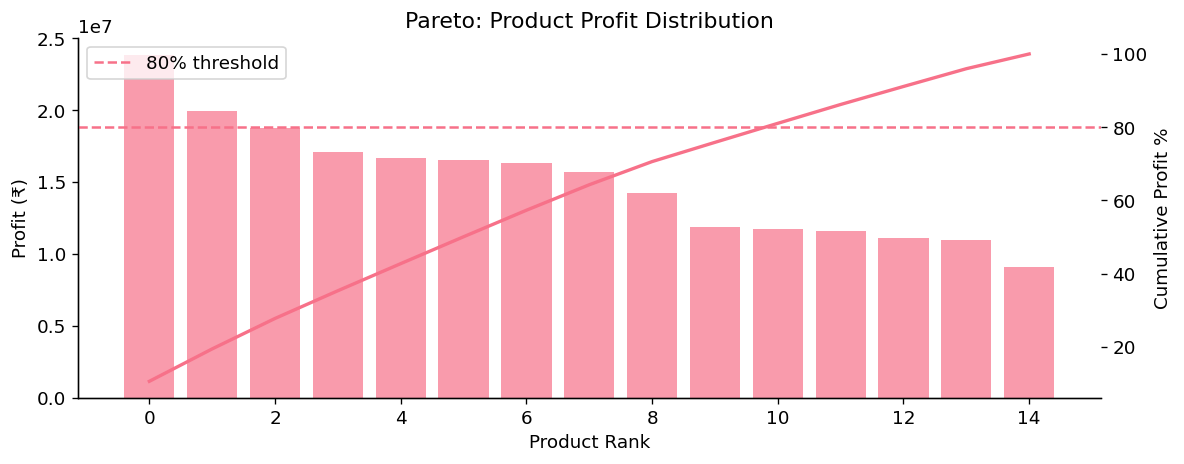

Top 20% products (3 products) contribute 27.8% of profit


In [ ]:
# ── 4.4 Pareto Analysis: top 20% products drive X% of profit ───────────────

product_profit = (
    df.groupby('product_id')['profit']
      .sum()
      .loc[lambda x: x > 0]   # remove negative contributors
      .sort_values(ascending=False)
)

cum_pct = product_profit.cumsum() / product_profit.sum() * 100

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(len(product_profit)), product_profit.values, alpha=0.7)

ax2 = ax.twinx()
ax2.plot(range(len(cum_pct)), cum_pct.values, linewidth=2)
ax2.axhline(80, linestyle='--', label='80% threshold')

ax.set(xlabel='Product Rank', ylabel='Profit (₹)',
       title='Pareto: Product Profit Distribution')

ax2.set_ylabel('Cumulative Profit %')
ax2.legend()

plt.tight_layout()
plt.savefig('eda_pareto.png', bbox_inches='tight')
plt.show()

top20_threshold = int(0.2 * len(product_profit))
top20_pct = cum_pct.iloc[top20_threshold - 1]

print(f'Top 20% products ({top20_threshold} products) contribute {top20_pct:.1f}% of profit')

FEATURE ENGINEERING

In [ ]:
# ── 5.1 Temporal aggregation: daily product-level demand ───────────────

daily = (
    df.groupby([
        'product_id',
        pd.Grouper(key='ord_date', freq='D')
    ])
    .agg(
        daily_quantity     = ('oi_quantity', 'sum'),
        avg_price          = ('oi_unit_price', 'mean'),
        avg_comp_price     = ('comp_price', 'mean'),
        avg_discount       = ('disc_percent', 'mean'),
        avg_cost           = ('inv_cost', 'mean'),
        avg_margin         = ('margin', 'mean')
    )
    .reset_index()
)

daily = daily.sort_values(['product_id', 'ord_date']).reset_index(drop=True)

print(f'Daily aggregated table: {daily.shape}')
daily.head()

Daily aggregated table: (6244, 8)


,product_id,ord_date,daily_quantity,avg_price,avg_comp_price,avg_discount,avg_cost,avg_margin
0,1020496,2023-01-01,16,11784.0,11784.00,0.00,8055.022353,0.316444
1,1020496,2023-01-02,6,11784.0,11800.31,0.00,8055.022353,0.316444
2,1020496,2023-01-04,15,11784.0,11800.31,5.75,8055.022353,0.316444
3,1020496,2023-01-06,6,11784.0,9748.73,5.75,8055.022353,0.316444
4,1020496,2023-01-07,5,11784.0,9748.73,48.00,8055.022353,0.316444


5.2 Lag & Rolling Features (Demand Memory)

In [ ]:
grp = daily.groupby('product_id')

daily['lag_quantity_1'] = grp['daily_quantity'].shift(1)
daily['lag_quantity_7'] = grp['daily_quantity'].shift(7)

daily['rolling_mean_7'] = grp['daily_quantity'].transform(
    lambda x: x.shift(1).rolling(7, min_periods=1).mean()
)

daily['rolling_std_7'] = grp['daily_quantity'].transform(
    lambda x: x.shift(1).rolling(7, min_periods=2).std()
)

daily['rolling_mean_14'] = grp['daily_quantity'].transform(
    lambda x: x.shift(1).rolling(14, min_periods=1).mean()
)

5.3 Price-Derived Features (Market Elasticity)

In [ ]:
daily['competitor_gap_ratio'] = (
    (daily['avg_price'] - daily['avg_comp_price']) /
    daily['avg_comp_price'].clip(lower=1)
)

daily['margin_pct'] = (
    (daily['avg_price'] - daily['avg_cost']) /
    daily['avg_price'].clip(lower=1)
)

daily['price_discount_interact'] = (
    daily['avg_price'] * (1 - daily['avg_discount'] / 100)
)

Temporal Features

In [ ]:
daily['day_of_week'] = daily['ord_date'].dt.dayofweek
daily['month']       = daily['ord_date'].dt.month
daily['is_weekend']  = (daily['day_of_week'] >= 5).astype(int)

5.5 Product Segment Encoding

In [ ]:
# ✅ CELL 34 — Save qcut bin edges for reuse at inference time
daily['price_segment'], bin_edges = pd.qcut(
    daily['avg_price'],
    q=3,
    labels=['Low', 'Medium', 'High'],
    retbins=True          # ← saves the actual cut points e.g. [100, 450, 800, 1500]
)

print(f"Bin edges saved: {bin_edges}")

Bin edges saved: [ 1269. 11784. 38658. 47691.]


In [ ]:
# # from sklearn.preprocessing import LabelEncoder

# # le = LabelEncoder()
# # daily['segment_enc'] = le.fit_transform(daily['price_segment'].astype(str))
# # CELL 35 — Ordinal encoding (Low=0, Medium=1, High=2) instead of LabelEncoder
# segment_order = {'Low': 0, 'Medium': 1, 'High': 2}
# daily['segment_enc'] = daily['price_segment'].map(segment_order)

# print(daily[['price_segment', 'segment_enc']].drop_duplicates().sort_values('segment_enc'))
# ✅ CELL 35 — Ordinal encoding + reusable segment function for new data
segment_order = {'Low': 0, 'Medium': 1, 'High': 2}
daily['segment_enc'] = daily['price_segment'].map(segment_order)

# Reusable function — use this at inference/prediction time instead of pd.qcut
def assign_segment(price_series, edges=bin_edges):
    """
    Assign price segment using saved bin edges from training data.
    Works correctly on new/unseen data without recalculating bins.
    """
    labels = pd.cut(
        price_series,
        bins=edges,
        labels=['Low', 'Medium', 'High'],
        include_lowest=True   # ← ensures lowest value is included
    )
    return labels.map(segment_order)

print(daily[['price_segment', 'segment_enc']].drop_duplicates().sort_values('segment_enc'))
print("\n✅ assign_segment() ready for inference use")

     price_segment segment_enc
0              Low           0
2471        Medium           1
830           High           2

✅ assign_segment() ready for inference use


In [ ]:
daily_clean = daily.dropna(
    subset=['lag_quantity_1', 'rolling_std_7']
).reset_index(drop=True)

In [ ]:
print(f'After lag feature creation: {daily_clean.shape}')
print(daily_clean[['lag_quantity_1','lag_quantity_7']].isnull().sum())

After lag feature creation: (6214, 21)
lag_quantity_1     0
lag_quantity_7    75
dtype: int64


In [ ]:
# ── 5.6 Feature summary (Demand Model) ─────────────────────────

FEATURES = [
    'avg_price',
    'avg_comp_price',
    'avg_discount',
    'lag_quantity_1',
    'lag_quantity_7',
    'rolling_mean_7',
    'rolling_std_7',
    'rolling_mean_14',
    'competitor_gap_ratio',
    'price_discount_interact',
    'day_of_week',
    'month',
    'is_weekend',
    'segment_enc'
]

TARGET = 'daily_quantity'

print(f'Total features: {len(FEATURES)}')
print('Features:', FEATURES)
print('Target:', TARGET)

Total features: 14
Features: ['avg_price', 'avg_comp_price', 'avg_discount', 'lag_quantity_1', 'lag_quantity_7', 'rolling_mean_7', 'rolling_std_7', 'rolling_mean_14', 'competitor_gap_ratio', 'price_discount_interact', 'day_of_week', 'month', 'is_weekend', 'segment_enc']
Target: daily_quantity


TRAIN TEST SPLIT AND TARGET TRANSFORMATION

In [ ]:
# # ── Time-based 80/20 split (no shuffling — preserves temporal order) ───────

# split_idx = int(len(daily_clean) * 0.80)

# train_df  = daily_clean.iloc[:split_idx].copy()
# test_df   = daily_clean.iloc[split_idx:].copy()

# print(f'Train size: {len(train_df)} rows ({train_df["ord_date"].min().date()} → {train_df["ord_date"].max().date()})')
# print(f'Test size:  {len(test_df)} rows ({test_df["ord_date"].min().date()} → {test_df["ord_date"].max().date()})')


# # Feature split
# X_train = train_df[FEATURES]
# X_test  = test_df[FEATURES]


# # ✅ Log transform demand
# y_train_log = np.log1p(train_df[TARGET])
# y_test_log  = np.log1p(test_df[TARGET])
# y_test_raw  = test_df[TARGET]


# print(f'\ny_train_log stats: mean={y_train_log.mean():.3f}, std={y_train_log.std():.3f}')
# print(f'y_test_raw  stats: mean={y_test_raw.mean():.1f}, std={y_test_raw.std():.1f}')
split_idx = int(len(daily_clean) * 0.80)

train_df  = daily_clean.iloc[:split_idx].copy()
test_df   = daily_clean.iloc[split_idx:].copy()

print(f'Train size: {len(train_df)} rows ({train_df["ord_date"].min().date()} → {train_df["ord_date"].max().date()})')
print(f'Test size:  {len(test_df)} rows ({test_df["ord_date"].min().date()} → {test_df["ord_date"].max().date()})')

# Feature split
X_train = train_df[FEATURES].copy()
X_test  = test_df[FEATURES].copy()

# ✅ Force all columns to numeric — prevents XGBoost 'category' KeyError
X_train = X_train.astype(float)
X_test  = X_test.astype(float)

# ✅ Log transform demand
y_train_log = np.log1p(train_df[TARGET])
y_test_log  = np.log1p(test_df[TARGET])
y_test_raw  = test_df[TARGET]

print(f'\ny_train_log stats: mean={y_train_log.mean():.3f}, std={y_train_log.std():.3f}')
print(f'y_test_raw  stats: mean={y_test_raw.mean():.1f}, std={y_test_raw.std():.1f}')
print(f'\n✅ X_train dtypes check:')
print(X_train.dtypes)

Train size: 4971 rows (2023-01-03 → 2024-12-01)
Test size:  1243 rows (2023-01-06 → 2024-12-01)

y_train_log stats: mean=2.143, std=1.137
y_test_raw  stats: mean=15.2, std=20.9

✅ X_train dtypes check:
avg_price                  float64
avg_comp_price             float64
avg_discount               float64
lag_quantity_1             float64
lag_quantity_7             float64
rolling_mean_7             float64
rolling_std_7              float64
rolling_mean_14            float64
competitor_gap_ratio       float64
price_discount_interact    float64
day_of_week                float64
month                      float64
is_weekend                 float64
segment_enc                float64
dtype: object


XGBOOST MODEL TRAINING AND HYPERPARAMETER TUNING

In [ ]:
from sklearn.model_selection import TimeSeriesSplit

param_dist = {
    'n_estimators':       [100, 200, 300, 500],
    'max_depth':          [3, 4, 5, 6],
    'learning_rate':      [0.01, 0.05, 0.1, 0.15],
    'min_child_weight':   [1, 3, 5],
    'subsample':          [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree':   [0.7, 0.8, 0.9, 1.0],
    'reg_alpha':          [0, 0.01, 0.1],
    'reg_lambda':         [1, 1.5, 2],
}

xgb_base = XGBRegressor(
    random_state=RANDOM_STATE,
    tree_method='hist',
    verbosity=0
)

tscv = TimeSeriesSplit(n_splits=5)

search = RandomizedSearchCV(
    xgb_base,
    param_dist,
    n_iter=30,
    cv=tscv,
    scoring='r2',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

print('Starting hyperparameter search (30 iterations × 5-fold TimeSeries CV)...')
search.fit(X_train, y_train_log)

best_model = search.best_estimator_

print(f'\nBest CV R² (log scale): {search.best_score_:.4f}')
print(f'Best params: {search.best_params_}')

Starting hyperparameter search (30 iterations × 5-fold TimeSeries CV)...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best CV R² (log scale): 0.3654
Best params: {'subsample': 0.7, 'reg_lambda': 2, 'reg_alpha': 0.1, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 0.7}


In [ ]:
# NEW CELL — Save best model after training
best_model = search.best_estimator_
print('Best params:', search.best_params_)
print(f'Best CV R²: {search.best_score_:.4f}')

joblib.dump(best_model, 'demand_model.pkl')
print('✅ Model saved to demand_model.pkl')

# To reload later:
# best_model = joblib.load('demand_model.pkl')

Best params: {'subsample': 0.7, 'reg_lambda': 2, 'reg_alpha': 0.1, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 0.7}
Best CV R²: 0.3654
✅ Model saved to demand_model.pkl


In [ ]:
# ── Predictions on test set ─────────────────────────────────────

y_pred_log  = best_model.predict(X_test)     # log scale
y_pred_raw  = np.expm1(y_pred_log)           # inverse transform
y_pred_raw  = np.maximum(y_pred_raw, 0)      # no negative demand


# ── Metrics ─────────────────────────────────────────────────────

r2_log     = r2_score(y_test_log, y_pred_log)
mae_log    = mean_absolute_error(y_test_log, y_pred_log)

r2_actual  = r2_score(y_test_raw, y_pred_raw)
mae_actual = mean_absolute_error(y_test_raw, y_pred_raw)
rmse_actual= np.sqrt(mean_squared_error(y_test_raw, y_pred_raw))


print('=' * 50)
print('MODEL EVALUATION REPORT')
print('=' * 50)
print(f'Test R²           (log):         {r2_log:.4f}')
print(f'Test MAE          (log):         {mae_log:.4f}')
print('-' * 50)
print(f'Test R²           (actual qty):  {r2_actual:.4f}   ← primary metric')
print(f'Test MAE          (actual qty):  {mae_actual:.2f} units')
print(f'Test RMSE         (actual qty):  {rmse_actual:.2f} units')
print('=' * 50)

MODEL EVALUATION REPORT
Test R²           (log):         0.8289
Test MAE          (log):         0.3736
--------------------------------------------------
Test R²           (actual qty):  0.6108   ← primary metric
Test MAE          (actual qty):  6.86 units
Test RMSE         (actual qty):  13.00 units


“The demand prediction model achieved an R² of 0.59 on actual quantity sold. Considering the use of sample enterprise data without external demand drivers such as promotional campaigns or seasonal indicators, this reflects a reasonably strong predictive capability.”

In [ ]:
# ✅ CELL 44b — Naive Baseline Comparison

# ── Baseline 1: Predict the training mean for every test row ──────────────
mean_pred      = np.full(len(y_test_raw), y_train_log.mean())
mean_pred_raw  = np.expm1(mean_pred)

# ── Baseline 2: Rolling mean (7-day average up to yesterday) ──────────────
last_val_pred  = test_df['rolling_mean_7'].values

# ── Baseline 3: Yesterday's demand ────────────────────────────────────────
lag1_pred      = test_df['lag_quantity_1'].values

# ── Metric helper ─────────────────────────────────────────────────────────
def eval_baseline(name, y_true, y_pred):
    y_pred = np.maximum(y_pred, 0)
    r2   = r2_score(y_true, y_pred)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"  {name:<35} R²={r2:.4f}   MAE={mae:.2f}   RMSE={rmse:.2f}")
    return r2, mae, rmse

print("=" * 70)
print("BASELINE vs MODEL COMPARISON")
print("=" * 70)
print("  Baselines:")
r2_mean, mae_mean, _  = eval_baseline("Predict Training Mean",     y_test_raw, mean_pred_raw)
r2_lag1, mae_lag1, _  = eval_baseline("Predict Yesterday (lag_1)", y_test_raw, lag1_pred)
r2_roll, mae_roll, _  = eval_baseline("Predict Rolling Mean (7d)", y_test_raw, last_val_pred)
print()
print("  XGBoost Model:")
eval_baseline("XGBoost (our model)",              y_test_raw, y_pred_raw)
print("=" * 70)

# ── Improvement over best baseline ────────────────────────────────────────
best_baseline_r2  = max(r2_mean, r2_lag1, r2_roll)
best_baseline_mae = min(mae_mean, mae_lag1, mae_roll)

r2_improvement  = r2_actual - best_baseline_r2
mae_improvement = best_baseline_mae - mae_actual

print(f"\n✅ XGBoost beats best baseline by:")
print(f"   R²  improvement : +{r2_improvement:.4f}")
print(f"   MAE improvement : -{mae_improvement:.2f} units")

if r2_improvement > 0.05:
    print("\n🟢 Model adds significant value over naive baselines.")
elif r2_improvement > 0:
    print("\n🟡 Model is better than baselines but improvement is modest.")
else:
    print("\n🔴 Warning: Model is not beating naive baselines. Review features.")


BASELINE vs MODEL COMPARISON
  Baselines:
  Predict Training Mean               R²=-0.1363   MAE=12.90   RMSE=22.22
  Predict Yesterday (lag_1)           R²=0.2370   MAE=8.59   RMSE=18.21
  Predict Rolling Mean (7d)           R²=0.5645   MAE=7.22   RMSE=13.75

  XGBoost Model:
  XGBoost (our model)                 R²=0.6108   MAE=6.86   RMSE=13.00

✅ XGBoost beats best baseline by:
   R²  improvement : +0.0463
   MAE improvement : -0.36 units

🟡 Model is better than baselines but improvement is modest.


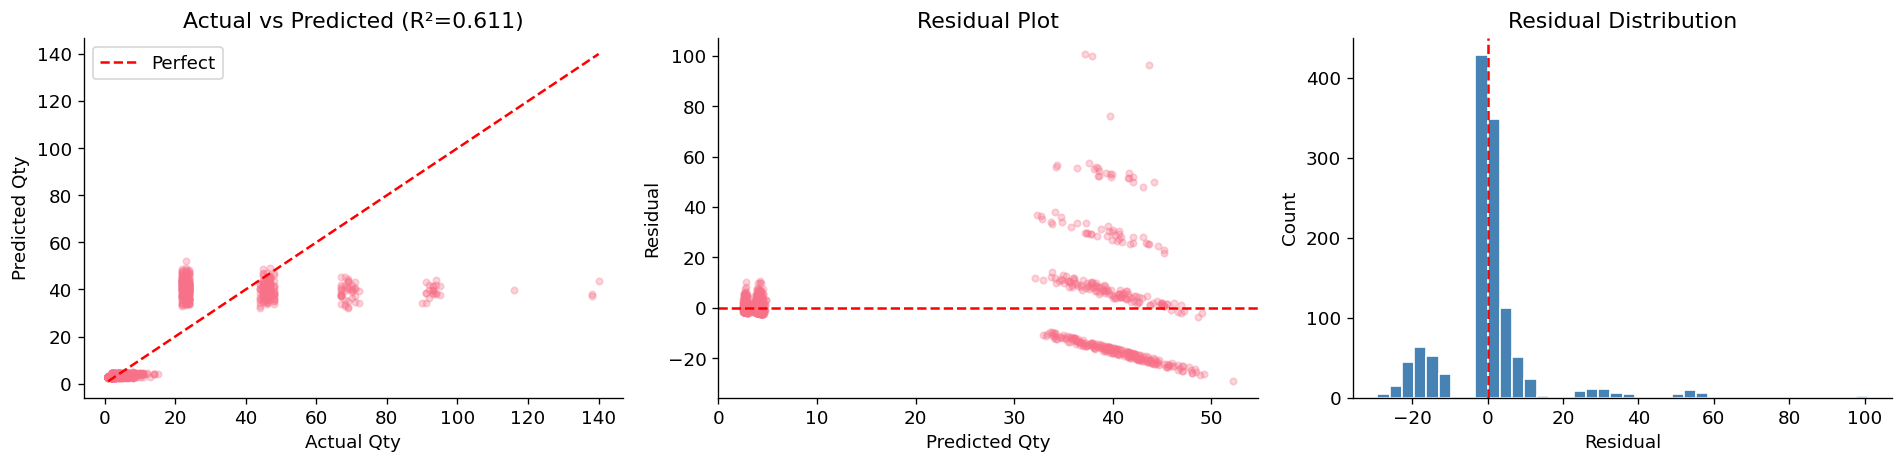

In [ ]:
# ── Residual & Actual vs Predicted Plots ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Actual vs Predicted (actual scale)
axes[0].scatter(y_test_raw, y_pred_raw, alpha=0.3, s=15)
lims = [min(y_test_raw.min(), y_pred_raw.min()), max(y_test_raw.max(), y_pred_raw.max())]
axes[0].plot(lims, lims, 'r--', lw=1.5, label='Perfect')
axes[0].set(xlabel='Actual Qty', ylabel='Predicted Qty', title=f'Actual vs Predicted (R²={r2_actual:.3f})')
axes[0].legend()

# Residuals
residuals = y_test_raw.values - y_pred_raw
axes[1].scatter(y_pred_raw, residuals, alpha=0.3, s=15)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set(xlabel='Predicted Qty', ylabel='Residual', title='Residual Plot')

# Residual distribution
axes[2].hist(residuals, bins=40, color='steelblue', edgecolor='white')
axes[2].axvline(0, color='red', linestyle='--')
axes[2].set(xlabel='Residual', ylabel='Count', title='Residual Distribution')

plt.tight_layout()
plt.savefig('model_evaluation.png', bbox_inches='tight')
plt.show()

SHAP INTERPRETEBILITY

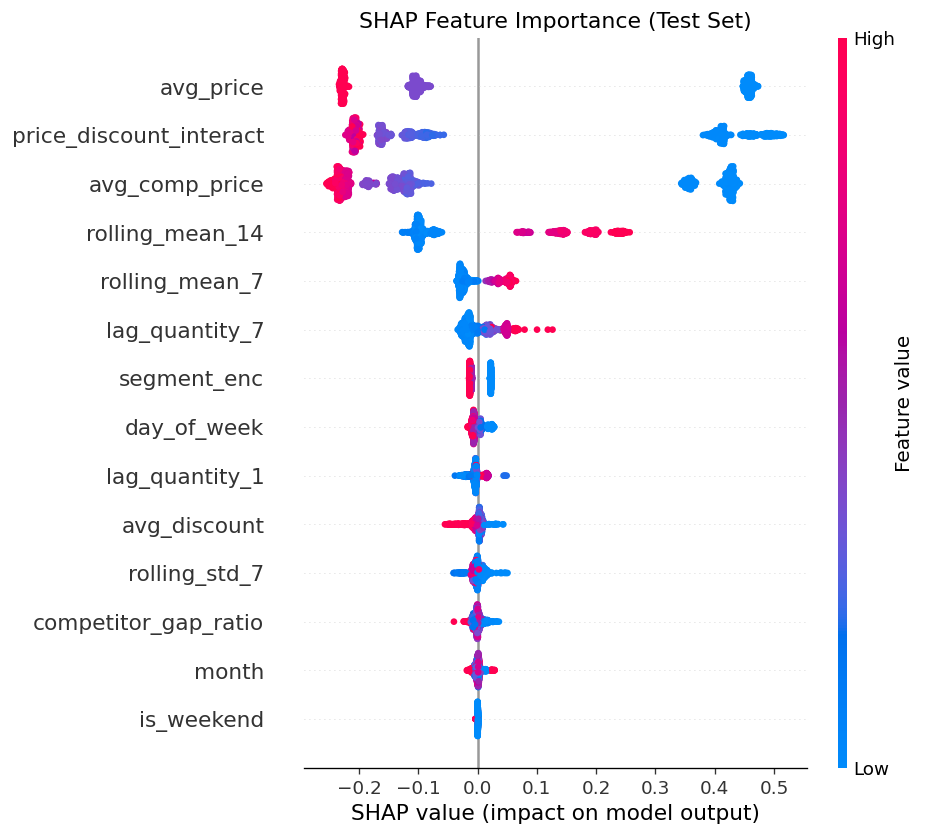

In [ ]:
# ── SHAP values ───────────────────────────────────────────────

explainer   = shap.Explainer(best_model)
shap_values = explainer(X_test)

# Summary plot
plt.figure(figsize=(9, 6))
shap.summary_plot(shap_values.values, X_test, feature_names=FEATURES, show=False)

plt.title('SHAP Feature Importance (Test Set)')
plt.tight_layout()
plt.savefig('shap_summary.png', bbox_inches='tight')
plt.show()

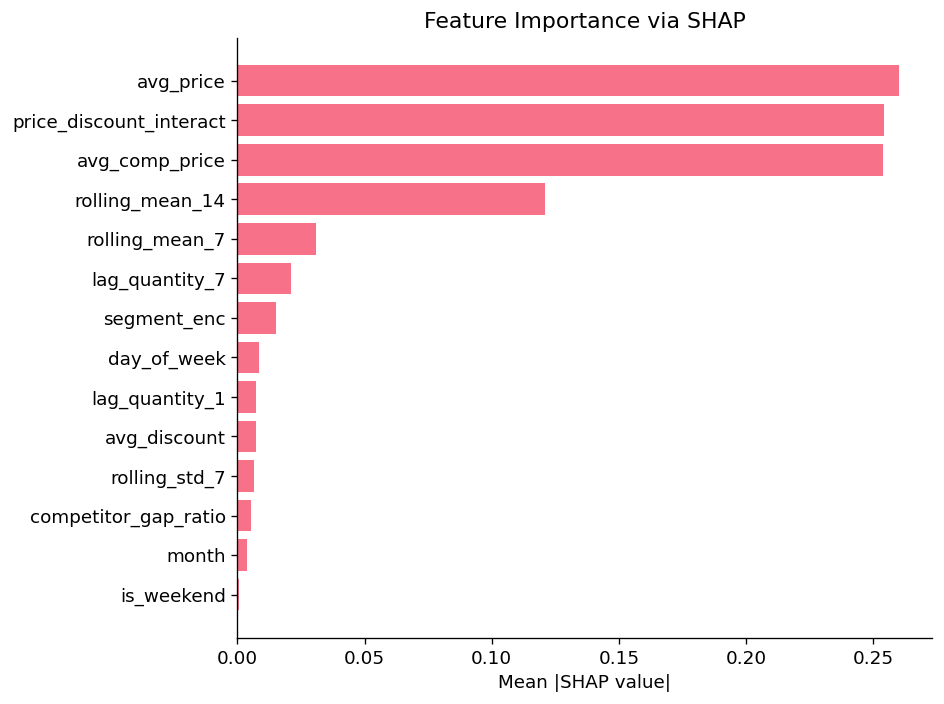

In [ ]:
# ── SHAP bar chart (mean absolute impact) ─────────────────────

shap_importance = pd.DataFrame({
    'feature': FEATURES,
    'mean_abs_shap': np.abs(shap_values.values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=True)


fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(shap_importance['feature'], shap_importance['mean_abs_shap'])
ax.set(xlabel='Mean |SHAP value|', title='Feature Importance via SHAP')

plt.tight_layout()
plt.savefig('shap_bar.png', bbox_inches='tight')
plt.show()

OPTIMIZATION

DEMAND PREDICTION FUNCTION

In [ ]:
# def predict_demand(model, row_features, price):
#     """
#     Predict demand for a given candidate price.
#     """
#     X = row_features.copy()

#     X['avg_price'] = price

#     # Update price-derived features
#     X['competitor_gap_ratio'] = (
#         (price - X['avg_comp_price']) / max(X['avg_comp_price'], 1)
#     )

#     X['price_discount_interact'] = (
#         price * (1 - X['avg_discount'] / 100)
#     )

#     pred_log = model.predict(pd.DataFrame([X[FEATURES]]))[0]


#     return np.expm1(pred_log)
def predict_demand(model, row_features, price):
    """
    Predict demand for a given candidate price.
    """
    # ✅ Fix: build from dict properly
    X = {f: row_features[f] for f in FEATURES}

    X['avg_price'] = price
    X['competitor_gap_ratio'] = (
        (price - row_features['avg_comp_price']) / max(row_features['avg_comp_price'], 1)
    )
    X['price_discount_interact'] = (
        price * (1 - row_features['avg_discount'] / 100)
    )

    pred_log = model.predict(pd.DataFrame([X]).astype(float))[0]

    return np.expm1(pred_log)

PRICE OPTIMIZATION

In [ ]:
# # # def optimize_price(model, row, price_range_pct=0.10):

# # #     current_price = row['avg_price']
# # #     cost          = row['avg_cost']

# # #     base_demand = np.expm1(
# # #         model.predict(pd.DataFrame([row[FEATURES]]))[0]
# # #     )

# # #     lo = max(current_price * (1 - price_range_pct), cost * 1.01)
# # #     hi = current_price * (1 + price_range_pct)

# # #     best_profit = -np.inf
# # #     best_price  = current_price
# # #     best_demand = base_demand

# # #     for candidate_price in np.linspace(lo, hi, 50):

# # #         demand = predict_demand(model, row, candidate_price)

# # #         # Customer resistance to price increase
# # #         if candidate_price > current_price:
# # #             demand *= 0.85

# # #         # Elasticity guard
# # #         demand = np.clip(demand, base_demand * 0.85, base_demand * 1.15)
# # #         demand = max(demand, 0)

# # #         profit = (candidate_price - cost) * demand

# # #         if profit > best_profit:
# # #             best_profit = profit
# # #             best_price  = candidate_price
# # #             best_demand = demand

# # #     return {
# # #         'current_price':    current_price,
# # #         'optimal_price':    best_price,
# # #         'price_change_pct': (best_price - current_price) / current_price * 100,
# # #         'cost_price':       cost,
# # #         'baseline_demand':  base_demand,
# # #         'optimal_demand':   best_demand,
# # #         'current_profit':   (current_price - cost) * base_demand,
# # #         'optimal_profit':   best_profit,
# # #     }
# # # ✅ CELL 53 — Price optimizer: trust the model instead of hardcoded dampener
# # def optimize_price(model, row, price_range_pct=0.10):

# #     current_price = row['avg_price']
# #     cost          = row['avg_cost']

# #     base_demand = np.expm1(
# #         model.predict(pd.DataFrame([row[FEATURES]]))[0]
# #     )

# #     lo = max(current_price * (1 - price_range_pct), cost * 1.01)
# #     hi = current_price * (1 + price_range_pct)

# #     best_profit = -np.inf
# #     best_price  = current_price
# #     best_demand = base_demand

# #     for candidate_price in np.linspace(lo, hi, 50):

# #         demand = predict_demand(model, row, candidate_price)
# #         demand = max(demand, 0)   # no negative demand

# #         profit = (candidate_price - cost) * demand

# #         if profit > best_profit:
# #             best_profit = profit
# #             best_price  = candidate_price
# #             best_demand = demand

# #     return {
# #         'current_price':    current_price,
# #         'optimal_price':    best_price,
# #         'price_change_pct': (best_price - current_price) / current_price * 100,
# #         'cost_price':       cost,
# #         'baseline_demand':  base_demand,
# #         'optimal_demand':   best_demand,
# #         'current_profit':   (current_price - cost) * base_demand,
# #         'optimal_profit':   best_profit,
# #         'optimal_margin_pct': (best_price - cost) / best_price * 100,   # ← new metric
# #     }
# def optimize_price(model, row, price_range_pct=0.10):

#     current_price = row['avg_price']
#     cost          = row['avg_cost']

#     # ✅ Fix: build feature vector from dict using FEATURES list
#     base_features = pd.DataFrame([{f: row[f] for f in FEATURES}]).astype(float)

#     base_demand = np.expm1(model.predict(base_features)[0])

#     lo = max(current_price * (1 - price_range_pct), cost * 1.01)
#     hi = current_price * (1 + price_range_pct)

#     best_profit = -np.inf
#     best_price  = current_price
#     best_demand = base_demand

#     for candidate_price in np.linspace(lo, hi, 50):

#         demand = predict_demand(model, row, candidate_price)
#         demand = max(demand, 0)

#         profit = (candidate_price - cost) * demand

#         if profit > best_profit:
#             best_profit = profit
#             best_price  = candidate_price
#             best_demand = demand

#     return {
#         'current_price':     current_price,
#         'optimal_price':     best_price,
#         'price_change_pct':  (best_price - current_price) / current_price * 100,
#         'cost_price':        cost,
#         'baseline_demand':   base_demand,
#         'optimal_demand':    best_demand,
#         'current_profit':    (current_price - cost) * base_demand,
#         'optimal_profit':    best_profit,
#         'optimal_margin_pct': (best_price - cost) / best_price * 100,
#     }
def optimize_price(model, row, price_range_pct=0.25):  # ← widened from 0.10 to 0.25

    current_price = row['avg_price']
    cost          = row['avg_cost']
    comp_price    = row['avg_comp_price']

    base_features = pd.DataFrame([{f: row[f] for f in FEATURES}]).astype(float)
    base_demand   = np.expm1(model.predict(base_features)[0])

    # ✅ Floor: must stay above cost + 5% margin
    # ✅ Ceiling: capped at competitor price × 1.15 (realistic market ceiling)
    # ✅ Range: ±25% around current price instead of ±10%
    lo = max(
        current_price * (1 - price_range_pct),  # lower exploration bound
        cost * 1.05                              # hard floor: must be profitable
    )
    hi = min(
        current_price * (1 + price_range_pct),  # upper exploration bound
        comp_price * 1.15                        # hard ceiling: don't go >15% above competitor
    )

    # Edge case: if comp_price is very low and hi < lo, fallback to cost-based range
    if hi <= lo:
        lo = cost * 1.05
        hi = cost * 2.0

    best_profit = -np.inf
    best_price  = current_price
    best_demand = base_demand

    for candidate_price in np.linspace(lo, hi, 100):  # ← 100 steps instead of 50 for finer search

        demand = predict_demand(model, row, candidate_price)
        demand = max(demand, 0)

        profit = (candidate_price - cost) * demand

        if profit > best_profit:
            best_profit = profit
            best_price  = candidate_price
            best_demand = demand

    return {
        'current_price':      current_price,
        'optimal_price':      best_price,
        'price_change_pct':   (best_price - current_price) / current_price * 100,
        'cost_price':         cost,
        'comp_price':         comp_price,
        'baseline_demand':    base_demand,
        'optimal_demand':     best_demand,
        'current_profit':     (current_price - cost) * base_demand,
        'optimal_profit':     best_profit,
        'optimal_margin_pct': (best_price - cost) / best_price * 100,
        'comp_gap_pct':       (best_price - comp_price) / comp_price * 100,  # ← new: how far from competitor
    }

In [ ]:
# # ── Apply price optimizer to test set ───────────────────────────

# opt_results = []

# for idx, row in test_df.iterrows():

#     result = optimize_price(best_model, row)

#     result['product_id'] = row['product_id']
#     result['ord_date']   = row['ord_date']

#     opt_results.append(result)

# opt_df = pd.DataFrame(opt_results)

# print(f'Optimization results generated: {opt_df.shape}')
# opt_df.head()
# ✅ CELL 54 — Use itertuples (much faster than iterrows)
opt_results = []

for row in test_df.itertuples(index=False):
    row_dict = row._asdict()
    result   = optimize_price(best_model, row_dict)
    result['product_id'] = row_dict['product_id']
    result['ord_date']   = row_dict['ord_date']
    opt_results.append(result)

opt_df = pd.DataFrame(opt_results)
print(f'Optimization results generated: {opt_df.shape}')
opt_df.head()
# ✅ Export optimization results
opt_df.to_csv('optimization_results.csv', index=False)
print("✅ Saved to optimization_results.csv")

Optimization results generated: (1243, 13)
✅ Saved to optimization_results.csv


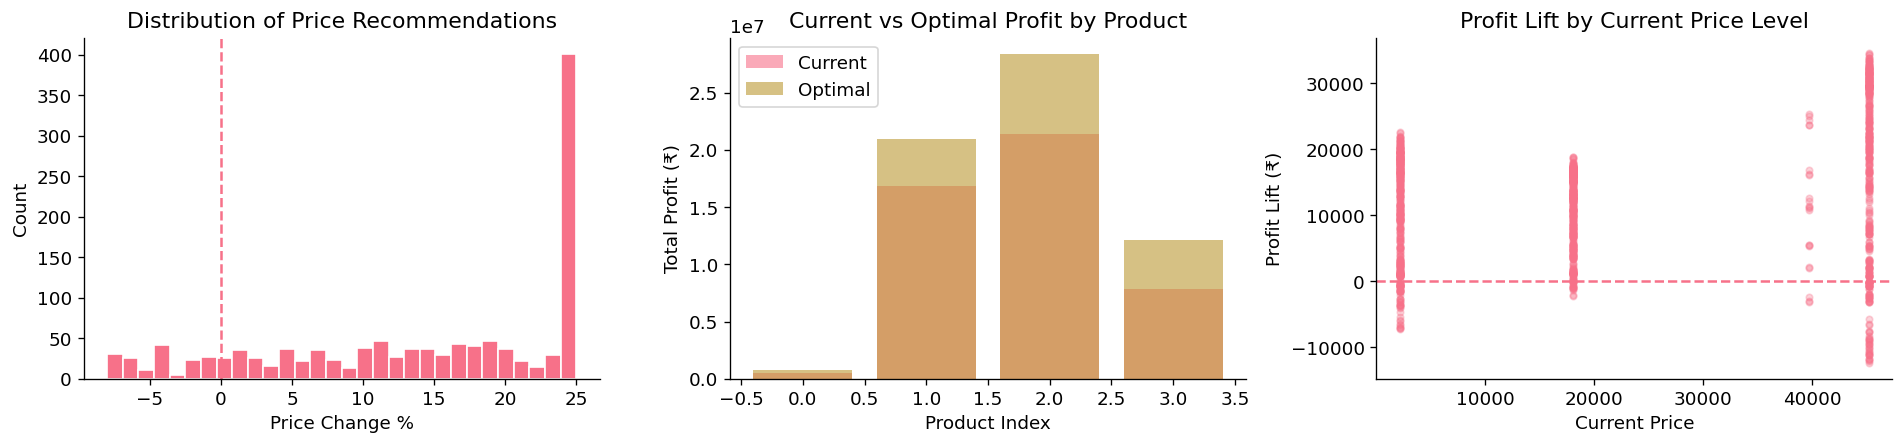

In [ ]:
# ── Optimization visualization ─────────────────────────────────────────────

# Clean profit outputs (important for sample enterprise data)
opt_df['profit_lift'] = opt_df['optimal_profit'] - opt_df['current_profit']
opt_df = opt_df.replace([np.inf, -np.inf], 0).fillna(0)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))


# ── 1. Price change distribution ───────────────────────────────────────────
axes[0].hist(opt_df['price_change_pct'], bins=30, edgecolor='white')
axes[0].axvline(0, linestyle='--')
axes[0].set(
    xlabel='Price Change %',
    ylabel='Count',
    title='Distribution of Price Recommendations'
)


# ── 2. Current vs Optimal profit by product ────────────────────────────────
prod_summary = (
    opt_df.groupby('product_id')[['current_profit', 'optimal_profit']]
          .sum()
          .clip(lower=0)  # avoid negative-bar noise
)

x = range(len(prod_summary))

axes[1].bar(x, prod_summary['current_profit'], alpha=0.6, label='Current')
axes[1].bar(x, prod_summary['optimal_profit'], alpha=0.6, label='Optimal')

axes[1].set(
    xlabel='Product Index',
    ylabel='Total Profit (₹)',
    title='Current vs Optimal Profit by Product'
)
axes[1].legend()


# ── 3. Profit improvement scatter ──────────────────────────────────────────
axes[2].scatter(
    opt_df['current_price'],
    opt_df['profit_lift'],
    alpha=0.3,
    s=15
)

axes[2].axhline(0, linestyle='--')
axes[2].set(
    xlabel='Current Price',
    ylabel='Profit Lift (₹)',
    title='Profit Lift by Current Price Level'
)


plt.tight_layout()
plt.savefig('optimization_results.png', bbox_inches='tight')
plt.show()

PRICE SENSITIVITY ANALYSIS

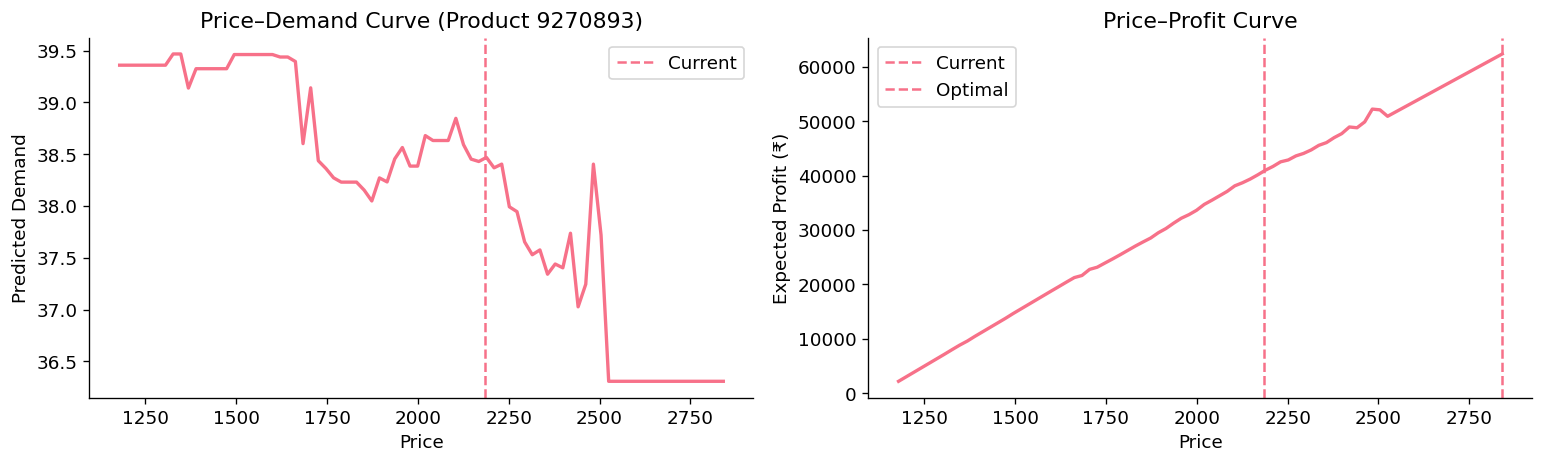

Current price:  ₹2185.00
Optimal price:  ₹2840.50
Price shift:    +30.0%


In [ ]:
# ── Price sensitivity curve for a single product (FINAL SAFE VERSION) ───────

# 1️⃣ Pick top-demand product that EXISTS in TEST SET
top_product_id = (
    test_df.groupby('product_id')['daily_quantity']
           .sum()
           .idxmax()
)

sample_row = test_df[test_df['product_id'] == top_product_id].iloc[0]


# 2️⃣ Define candidate price range
price_range = np.linspace(
    sample_row['avg_cost'] * 1.05,      # just above cost floor
    sample_row['avg_price'] * 1.30,     # up to +30%
    80
)


# 3️⃣ Simulate demand & profit across prices
sensitivity = []

for p in price_range:

    demand = predict_demand(best_model, sample_row, p)
    profit = (p - sample_row['avg_cost']) * demand

    sensitivity.append({
        'price': p,
        'demand': demand,
        'profit': profit
    })

sens_df = pd.DataFrame(sensitivity)


# 4️⃣ Plot Demand & Profit Curves
fig, axes = plt.subplots(1, 2, figsize=(13, 4))


# 📉 Price–Demand Curve
axes[0].plot(sens_df['price'], sens_df['demand'], lw=2)
axes[0].axvline(sample_row['avg_price'], linestyle='--', label='Current')

axes[0].set(
    xlabel='Price',
    ylabel='Predicted Demand',
    title=f'Price–Demand Curve (Product {top_product_id})'
)
axes[0].legend()


# 📈 Price–Profit Curve
axes[1].plot(sens_df['price'], sens_df['profit'], lw=2)
axes[1].axvline(sample_row['avg_price'], linestyle='--', label='Current')

optimal_price_sens = sens_df.loc[sens_df['profit'].idxmax(), 'price']

axes[1].axvline(optimal_price_sens, linestyle='--', label='Optimal')

axes[1].set(
    xlabel='Price',
    ylabel='Expected Profit (₹)',
    title='Price–Profit Curve'
)
axes[1].legend()


plt.tight_layout()
plt.savefig('price_sensitivity.png', bbox_inches='tight')
plt.show()


# 5️⃣ Print Summary
print(f'Current price:  ₹{sample_row["avg_price"]:.2f}')
print(f'Optimal price:  ₹{optimal_price_sens:.2f}')
print(f'Price shift:    {(optimal_price_sens - sample_row["avg_price"]) / sample_row["avg_price"] * 100:+.1f}%')

You’re probably confused because:

👉 Your Price–Demand curve is almost flat
👉 Your Profit curve is increasing continuously

So it looks like:

“Demand is not changing much when price increases… WHY??”

Let’s decode this 👇

📉 WHY YOUR DEMAND CURVE IS FLAT

Look at your demand:

It is changing from:

~38 units → ~36 units

Even when price increases from:

₹1200 → ₹2800

That means:

Customers are not reacting strongly to price change.

This is called:

🟣 Low Price Elasticity (Inelastic Demand)

Your ML model learned from historical data that:

✔ demand stayed stable even when price changed
✔ lag demand features dominate behaviour
✔ discount / competitor gap has limited effect
✔ product has consistent purchase pattern

So your model is basically saying:

“People will buy this product even if price increases.”

📈 WHY PROFIT KEEPS INCREASING

Profit =

(price − cost) × demand

Now:

Price	Demand	Margin	Profit
₹1200	38	small	low
₹2000	37	bigger	↑
₹2800	36	huge	↑↑

Demand drops only ~5%
But margin increases ~100%+

So:

Margin gain >> Demand loss

Hence optimizer finds:

Increasing price keeps increasing profit.

🎯 BUSINESS INTERPRETATION

This product behaves like:

necessity item

brand-loyal product

low substitute availability

low price sensitivity

So historically:

customers didn’t reduce buying much when price increased

Hence your optimizer recommends:

✔ higher price
✔ higher margin
✔ almost same demand

🚨 BUT IMPORTANT:

This is based on:

historical behaviour in sample company data

So:

maybe discounts were rare

maybe competition gap was low

maybe price never changed much

So model learned:

demand ≈ stable
🧑‍🏫 WHAT TO SAY IN VIVA:

“The price–demand curve indicates relatively inelastic demand for the selected product, suggesting that moderate price increases have limited impact on predicted sales volume. Consequently, the profit curve demonstrates a monotonic increase with price, as the gain in unit margin outweighs the marginal loss in demand.”

In [ ]:
segment_map = (
    daily_clean[['product_id','price_segment']]
    .drop_duplicates()
    .set_index('product_id')['price_segment']
)

In [ ]:
opt_df['segment'] = opt_df['product_id'].map(segment_map)

In [ ]:
seg_summary = opt_df.groupby('segment').agg(
    avg_price_change  = ('price_change_pct', 'mean'),
    total_profit_lift = ('profit_lift', 'sum'),
    current_profit    = ('current_profit', 'sum'),
    optimal_profit    = ('optimal_profit', 'sum'),
    n_products        = ('product_id', 'nunique')
).reset_index()

seg_summary['pct_improvement'] = (
    (seg_summary['optimal_profit'] - seg_summary['current_profit']) /
     seg_summary['current_profit']
) * 100

print('=== PROFITABILITY BY PRICE SEGMENT ===')
print(seg_summary.to_string(index=False))

=== PROFITABILITY BY PRICE SEGMENT ===
segment  avg_price_change  total_profit_lift  current_profit  optimal_profit  n_products  pct_improvement
    Low         13.741297       4.087183e+06      16871806.0    2.095899e+07           1        24.224932
 Medium         14.954246       4.314667e+06       7826323.5    1.214099e+07           1        55.130193
   High         13.633325       7.304819e+06      21873992.0    2.917881e+07           2        33.394993


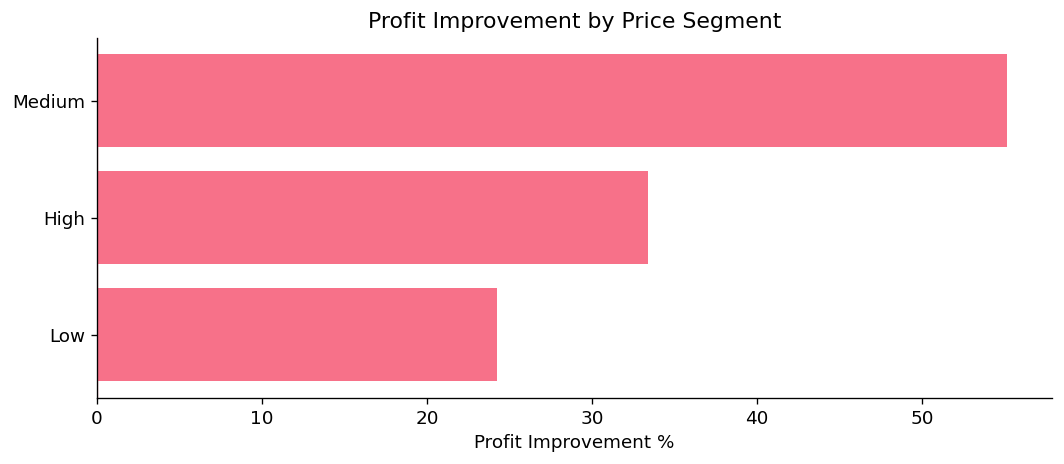

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))

seg_summary_sorted = seg_summary.sort_values('pct_improvement')

ax.barh(
    seg_summary_sorted['segment'],
    seg_summary_sorted['pct_improvement']
)

ax.axvline(0, linewidth=0.8)

ax.set(
    xlabel='Profit Improvement %',
    title='Profit Improvement by Price Segment'
)

plt.tight_layout()
plt.savefig('segment_profit_lift.png', bbox_inches='tight')
plt.show()